Paso 1: Inicialización de Herramientas Analíticas
- Descripción: "Cargamos el ecosistema de librerías necesarias para el tratamiento de datos y la creación de componentes visuales, asegurando un entorno preparado para el análisis del catálogo."

In [1]:
# Importación del stack para manipulación de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de salida gráfica
%matplotlib inline

Paso 2: Ingesta del Catálogo de Precios de Compra
- Descripción: "Importamos el set de datos original que contiene la información de productos y costos. Utilizamos el lector de archivos delimitados para asignar la información a una estructura de DataFrame."

In [2]:
# Lectura de la fuente de datos mediante el motor de pandas
df_catalogo_base = pd.read_table("../data/2017PurchasePricesDec.csv", sep=',')

Paso 3: Diagnóstico de Volumen y Dimensiones
- Descripción: "Evaluamos la magnitud del dataset mediante la inspección de su forma (filas y columnas). Este paso nos permite confirmar la cantidad total de SKU registrados en el archivo fuente."

In [3]:
# Verificación del tamaño del arreglo de datos
dimensiones_dataset = df_catalogo_base.shape
print(f"Estructura del dataset: {dimensiones_dataset}")

Estructura del dataset: (12261, 9)


Paso 4: Muestreo de Registros Iniciales
- Descripción: "Realizamos una exploración visual de los primeros registros del catálogo para validar la correcta disposición de las columnas y el contenido de las celdas."

In [4]:
# Visualización de los 5 elementos superiores del catálogo
df_catalogo_base.iloc[:5]

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Paso 5: Auditoría de Tipos de Datos
- Descripción: "Verificamos la naturaleza técnica de cada columna. Es fundamental corroborar si los precios, códigos y descripciones han sido interpretados correctamente por el sistema para evitar errores de cálculo."

In [5]:
# Inspección de los metadatos de las columnas
resumen_tipos = df_catalogo_base.info()
print(df_catalogo_base.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12261 entries, 0 to 12260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           12261 non-null  int64  
 1   Description     12260 non-null  object 
 2   Price           12261 non-null  float64
 3   Size            12260 non-null  object 
 4   Volume          12260 non-null  object 
 5   Classification  12261 non-null  int64  
 6   PurchasePrice   12261 non-null  float64
 7   VendorNumber    12261 non-null  int64  
 8   VendorName      12261 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 862.2+ KB
Brand               int64
Description        object
Price             float64
Size               object
Volume             object
Classification      int64
PurchasePrice     float64
VendorNumber        int64
VendorName         object
dtype: object


Paso 6: Cuantificación de Vacíos de Información
- Descripción: "Realizamos un escaneo total de la matriz para identificar la cantidad de registros faltantes por cada variable. Este diagnóstico es fundamental para determinar la integridad de los datos de costos y medidas."

In [6]:
# Evaluación de celdas vacías por categoría
conteo_nulos_catalogo = df_catalogo_base.isna().sum()
print(conteo_nulos_catalogo)

Brand             0
Description       1
Price             0
Size              1
Volume            1
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64


Paso 7: Localización de Registros Incompletos
- Descripción: "Filtramos y aislamos las filas que presentan al menos un campo nulo. Esta inspección nos permite ver el contenido de los registros que requieren saneamiento antes de avanzar con el análisis."

In [7]:
# Identificación de filas con inconsistencias (nulos)
filas_con_vacios = df_catalogo_base[df_catalogo_base.isnull().any(axis=1)]

# Validación de salida según el hallazgo
if not filas_con_vacios.empty:
    print("Registros con campos nulos localizados:")
    display(filas_con_vacios)
else:
    print("No se detectaron registros incompletos en el catálogo.")

Registros con campos nulos localizados:


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
7915,4202,NaN,0.0,NaN,NaN,1,11.19,480,BACARDI USA INC


Paso 8: Análisis de Diversidad en Dimensiones (Size y Volume)
- Descripción: "Exploramos los valores distintos registrados en las columnas de tamaño y volumen. El objetivo es identificar la variedad de formatos de empaque y capacidades que componen el inventario."

In [8]:
# Extracción de valores únicos para métricas de empaque
formatos_medida = df_catalogo_base['Size'].unique()
volumenes_registrados = df_catalogo_base['Volume'].unique()

print(f"Formatos de envase (Size): {formatos_medida}")
print(f"Capacidades detectadas (Volume): {volumenes_registrados}")

Formatos de envase (Size): ['750mL' '1000mL' '1750mL' '50mL' '375mL' '100mL 4 Pk' '50mL 5 Pk' '100mL'
 '200mL' '50mL 4 Pk' '50mL 3 Pk' '300mL' '200mL 4 Pk' 'Unknown'
 '750mL 2 Pk' '250mL 4 Pk' '1500mL' '3000mL' '5000mL' '4000mL'
 '187mL 4 Pk' '150mL' '187mL' '500mL' '720mL' '650mL' '200mL 3 Pk'
 '187mL 3 Pk' '330mL' '250mL' '750mL + 3/' '18000mL' '180mL' '750mL + 4/'
 '6000mL' '1000mL 2 Pk' '750mL 12 P' '750mL 6 Pk' '20mL 5 Pk' nan
 '375mL 2 Pk' '20000mL' '50mL 12 Pk' '750mL 3 Pk' '375mL 3 Pk'
 '750mL + 1/' '200mL 5 Pk' '162.5mL' '400mL' '1100ml' '600mL' '19500mL'
 '560mL' '3750mL' '750mL  3' '1500ml' '9000mL']
Capacidades detectadas (Volume): ['750' '1000' '1750' '50' '375' '100' '200' '300' 'Unknown' '250' '1500'
 '3000' '5000' '4000' '187' '150' '500' '720' '650' '330' '18000' '180'
 '6000' '20' nan '20000' '162.5' '400' '1100' '600' '19500' '560' '3750'
 '9000']


Paso 9: Distribución de Frecuencia de Formatos
- Descripción: "Contabilizamos cuántos productos existen por cada tipo de tamaño (Size). Esto nos permite conocer la distribución de stock según la presentación física del producto."

In [9]:
# Conteo de frecuencia de apariciones por cada formato
distribucion_formatos = df_catalogo_base['Size'].value_counts()
print(distribucion_formatos)

Size
750mL          9823
1500mL          486
1750mL          433
1000mL          427
375mL           318
50mL            276
3000mL          104
187mL            52
500mL            51
187mL 4 Pk       48
5000mL           44
200mL            26
300mL            24
4000mL           16
1500ml           11
720mL            11
100mL             8
750mL 2 Pk        6
250mL 4 Pk        6
50mL 4 Pk         6
330mL             5
180mL             5
50mL 3 Pk         5
20000mL           5
50mL 5 Pk         4
200mL 3 Pk        4
6000mL            4
Unknown           4
187mL 3 Pk        4
375mL 2 Pk        3
200mL 4 Pk        3
750mL 3 Pk        3
18000mL           3
250mL             3
150mL             2
100mL 4 Pk        2
375mL 3 Pk        2
750mL + 3/        2
750mL 6 Pk        2
600mL             2
560mL             2
20mL 5 Pk         1
750mL + 4/        1
1000mL 2 Pk       1
650mL             1
750mL 12 P        1
750mL + 1/        1
50mL 12 Pk        1
400mL             1
162.5mL        

Paso 10: Segmentación de Productos en Pack (Pk)
- Descripción: "Filtramos el catálogo para detectar productos que se comercializan en paquetes agrupados. Seleccionamos registros únicos para analizar cómo se clasifican y describen estos formatos especiales."

In [10]:
# Localización de etiquetas que contienen 'Pk'
df_segmento_packs = df_catalogo_base[df_catalogo_base['Size'].str.contains('Pk', na=False)]

# Reducción a ejemplares únicos por formato para visualización de referencia
muestreo_variedad_pack = df_segmento_packs.drop_duplicates(subset='Size')

# Impresión de columnas seleccionadas (Formato, Descripción y Clasificación)
print(muestreo_variedad_pack[['Size', 'Description', 'Classification']])

              Size                   Description  Classification
113     100mL 4 Pk  Glenmorangie Collection 4 Pk               1
115      50mL 5 Pk      Malibu 50ml Sampler Pack               1
330      50mL 4 Pk  Jack Daniels Family 4 Pk/50m               1
363      50mL 3 Pk              Crown Royal Trio               1
398     200mL 4 Pk   Johnnie Walker Collection 4               1
641     750mL 2 Pk  Bombay Sapphire & East 2 Pak               1
932     250mL 4 Pk    Goslings Dark'N Stormy RTD               1
1480    187mL 4 Pk     Sutter Home Clsc Wh Znfdl               2
3690    200mL 3 Pk  St George Gin 3/200mls Combo               1
3762    187mL 3 Pk        Cavit Prosecco Lunetta               2
6918   1000mL 2 Pk  Grey Goose 2Pak Cherry/Origi               1
7737    750mL 6 Pk    Viberti Mixed Wooden Box 6               2
7858     20mL 5 Pk  The Bitter Truth 5/20mls Pak               1
8754    375mL 2 Pk       Maker's Mark Combo Pack               1
8864    50mL 12 Pk    12 

Paso 11: Identificación de Marcas con Medida Desconocida
- Descripción: "Localizamos los registros donde la dimensión del producto está marcada como 'Unknown' y extraemos sus identificadores de marca para determinar el tratamiento específico que requieren."

In [11]:
# Ubicamos los IDs de marca asociados a dimensiones no especificadas usando loc
indices_medida_desconocida = df_catalogo_base.loc[df_catalogo_base['Size'] == 'Unknown', 'Brand']

# Visualización de los resultados obtenidos
print(indices_medida_desconocida)

542       2993
5921      9908
8795      8992
10009    90590
Name: Brand, dtype: int64


Paso 12: Imputación Manual de Medidas Críticas
- Descripción: "Saneamos los valores desconocidos basándonos en el conocimiento técnico del inventario. Asignamos una medida específica a la marca de producto y marcamos como 'No Aplica' a los artículos de cristalería, asegurando la precisión de los datos."

In [12]:
# Aplicamos correcciones específicas mediante máscaras de selección
# Caso marca 2993: Asignación de medida 200
df_catalogo_base.loc[df_catalogo_base['Brand'] == 2993, 'Size'] = '200'

# Casos de cristalería: Aplicación de etiqueta 'No Aplica'
articulos_vidrio = [9908, 8992, 90590]
df_catalogo_base.loc[df_catalogo_base['Brand'].isin(articulos_vidrio), 'Size'] = 'No Aplica'

# Verificación de la actualización de los registros modificados
print(df_catalogo_base[df_catalogo_base['Brand'].isin([2993] + articulos_vidrio)])

       Brand                   Description  Price       Size   Volume  \
542     2993             Angostura Bitters   7.49        200  Unknown   
5921    9908      Tito's Copper Mug 2 Pack  21.01  No Aplica  Unknown   
8795    8992                      Group 92   1.99  No Aplica  Unknown   
10009  90590  Overture Champagne 2Glass Pk  19.95  No Aplica  Unknown   

       Classification  PurchasePrice  VendorNumber  \
542                 1           5.39          5895   
5921                1          16.15          4425   
8795                1           1.43          1703   
10009               2          13.12          4425   

                                VendorName  
542            Mizkan Americas, Inc.        
5921                 MARTIGNETTI COMPANIES  
8795   ALISA CARR BEVERAGES                 
10009                MARTIGNETTI COMPANIES  


Paso 13: Análisis de Formatos con Caracteres Especiales
- Descripción: "Detectamos y aislamos los productos cuyas medidas contienen barras diagonales. Analizamos estos casos mediante una reducción a valores únicos para entender si representan empaques compuestos o medidas alternativas."

In [13]:
# Filtrado de formatos que incluyen el caracter "/"
registros_especiales = df_catalogo_base[df_catalogo_base['Size'].str.contains('/', na=False)]

# Extracción de ejemplares únicos para estudio de patrones de empaque
muestreo_formatos = registros_especiales.drop_duplicates(subset=['Size'])

# Visualización de las columnas relevantes para inspección
print(muestreo_formatos[['Size', 'Description']])

             Size                 Description
3974   750mL + 3/   Glenmorangie Original VAP
5432   750mL + 4/     Red Stag VAP 750+4/50ml
10191  750mL + 1/  Crown Royal Shot Glass VAP


Paso 14: Descomposición de la Columna de Medida (Size y Pack)
- Descripción: "Implementamos un proceso de ingeniería de variables para separar el volumen del formato de empaque. Mediante una función personalizada, dividimos la información en dos nuevas dimensiones que permiten un análisis más granular."

In [14]:
# Definición de lógica de partición de texto alternativa
def procesar_dimensiones(valor_size):
    # Gestión de excepciones para valores nulos o genéricos
    if pd.isna(valor_size) or any(k in str(valor_size) for k in ['Unknown', 'No Aplica']):
        return pd.Series(['No Aplica', 'No Aplica'])
    
    # Fragmentación de la cadena y extracción de componentes
    partes_texto = str(valor_size).split(' ')
    magnitud_base = partes_texto[0].strip()
    
    # Consolidación del resto de la cadena como información de Pack
    detalle_empaque = "".join(partes_texto[1:]) if len(partes_texto) > 1 else 'No Aplica'
    
    return pd.Series([magnitud_base, detalle_empaque])

# Aplicación de la función para generar las columnas 'Size' y 'Pack' simultáneamente
df_catalogo_base[['Size', 'Pack']] = df_catalogo_base['Size'].apply(procesar_dimensiones)

# Verificación de la nueva estructura (primeros 400 registros)
print(df_catalogo_base[['Size', 'Pack']].head(400))

      Size       Pack
0    750mL  No Aplica
1    750mL  No Aplica
2    750mL  No Aplica
3    750mL  No Aplica
4    750mL  No Aplica
..     ...        ...
395  750mL  No Aplica
396  750mL  No Aplica
397  750mL  No Aplica
398  200mL        4Pk
399  750mL  No Aplica

[400 rows x 2 columns]


Paso 15: Validación de la Nueva Categorización
- Descripción: "Auditamos la columna de medidas tras el proceso de separación. Este recuento nos permite confirmar que la limpieza ha sido efectiva y que los datos están normalizados."

In [15]:
# Recuento de frecuencia de las nuevas etiquetas de medida
conteo_unidades_ajustadas = df_catalogo_base['Size'].value_counts()
print(conteo_unidades_ajustadas)

Size
750mL        9840
1500mL        486
1750mL        433
1000mL        428
375mL         323
50mL          292
3000mL        104
187mL         104
500mL          51
5000mL         44
200mL          34
300mL          24
4000mL         16
720mL          11
1500ml         11
100mL          10
250mL           9
330mL           5
20000mL         5
180mL           5
6000mL          4
No Aplica       4
18000mL         3
560mL           2
600mL           2
150mL           2
200             1
650mL           1
20mL            1
162.5mL         1
400mL           1
19500mL         1
1100ml          1
3750mL          1
9000mL          1
Name: count, dtype: int64


Paso 16: Inspección de Registros con Formato Pack
- Descripción: "Aislamos los productos que han sido identificados con un formato de empaque múltiple (diferente a 'No Aplica'). Esta vista nos permite validar que la separación de columnas en el paso anterior se realizó correctamente para los artículos agrupados."

In [16]:
# Filtramos el catálogo para extraer únicamente los productos en formato Pack
registros_con_pack = df_catalogo_base.query("Pack != 'No Aplica'")

# Visualización de los primeros 50 ejemplares detectados
registros_con_pack.head(50)

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName,Pack
113,1133,Glenmorangie Collection 4 Pk,31.99,100mL,100,1,23.01,8112,MOET HENNESSY USA INC,4Pk
115,1136,Malibu 50ml Sampler Pack,4.99,50mL,50,1,3.87,17035,PERNOD RICARD USA,5Pk
160,1365,Stoli Mini Bar 5/50mLs Pack,7.99,50mL,50,1,6.05,8664,"STOLI GROUP,(USA) LLC",5Pk
330,2250,Jack Daniels Family 4 Pk/50m,12.99,50mL,50,1,9.69,1128,BROWN-FORMAN CORP,4Pk
363,2453,Crown Royal Trio,5.99,50mL,50,1,4.31,3960,DIAGEO NORTH AMERICA INC,3Pk
398,2604,Johnnie Walker Collection 4,99.99,200mL,200,1,73.52,3960,DIAGEO NORTH AMERICA INC,4Pk
641,3341,Bombay Sapphire & East 2 Pak,34.99,750mL,750,1,25.17,480,BACARDI USA INC,2Pk
932,4062,Goslings Dark'N Stormy RTD,7.99,250mL,250,1,5.83,1485,CASTLE BRANDS CORP.,4Pk
940,4105,Patron XO Cafe Variety 3 Pak,6.99,50mL,50,1,5.07,9165,ULTRA BEVERAGE COMPANY LLP,3Pk
1127,4881,Bacardi Twin Pack 2/750mls,19.99,750mL,750,1,14.81,480,BACARDI USA INC,2Pk


Paso 17: Diagnóstico de Inconsistencias en Volumen
- Descripción: "Buscamos registros donde la columna de Volumen presente valores 'Unknown' o nulos. Este control es preventivo para asegurar que toda la información cuantitativa esté disponible para futuros cálculos de inventario."

In [17]:
# Identificamos filas con volumen indeterminado o vacío mediante máscaras lógicas
filas_volumen_incognito = df_catalogo_base.loc[df_catalogo_base['Volume'] == 'Unknown']
filas_volumen_vacias = df_catalogo_base[df_catalogo_base['Volume'].isna()]

# Reporte de hallazgos técnicos
print("Registros 'Unknown' en la variable Volume:")
print(filas_volumen_incognito)

print("\nRegistros con NaN en la variable Volume:")
print(filas_volumen_vacias)

Registros 'Unknown' en la variable Volume:
       Brand                   Description  Price       Size   Volume  \
542     2993             Angostura Bitters   7.49        200  Unknown   
5921    9908      Tito's Copper Mug 2 Pack  21.01  No Aplica  Unknown   
8795    8992                      Group 92   1.99  No Aplica  Unknown   
10009  90590  Overture Champagne 2Glass Pk  19.95  No Aplica  Unknown   

       Classification  PurchasePrice  VendorNumber  \
542                 1           5.39          5895   
5921                1          16.15          4425   
8795                1           1.43          1703   
10009               2          13.12          4425   

                                VendorName       Pack  
542            Mizkan Americas, Inc.        No Aplica  
5921                 MARTIGNETTI COMPANIES  No Aplica  
8795   ALISA CARR BEVERAGES                 No Aplica  
10009                MARTIGNETTI COMPANIES  No Aplica  

Registros con NaN en la variable Volume

Paso 18: Verificación Final de Integridad de Datos
- Descripción: "Realizamos un nuevo conteo de valores nulos tras los procesos de limpieza y transformación. Este paso confirma si las acciones de imputación y separación de columnas eliminaron los vacíos de información detectados al inicio."

In [18]:
# Resumen de estado de columnas tras el procesamiento
estado_nulos_final = df_catalogo_base.isna().sum()
print(estado_nulos_final)

Brand             0
Description       1
Price             0
Size              0
Volume            1
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
Pack              0
dtype: int64

Paso 19: Auditoría de Redundancias (Duplicados)
- Descripción: "Evaluamos la existencia de registros idénticos en el catálogo. Un catálogo maestro no debe contener filas duplicadas para evitar errores en la valoración del stock; en caso de existir, procedemos a su cuantificación e inspección."

In [19]:
# Verificación de integridad mediante el conteo de filas repetidas
total_duplicados = df_catalogo_base.duplicated().sum()

print(f"Número de registros duplicados en el catálogo: {total_duplicados}")

# Despliegue de los registros redundantes si se detectan
if total_duplicados > 0:
    print("Detalle de filas duplicadas:")
    display(df_catalogo_base[df_catalogo_base.duplicated(keep=False)])

Número de registros duplicados en el catálogo: 0


Paso 20: Identificación de Inconsistencias en la Descripción
- Descripción: "Localizamos específicamente el registro que presenta un valor faltante en la columna de Descripción. Este saneamiento puntual es crítico para asegurar que cada ID de producto esté asociado a un nombre de artículo válido."

In [20]:
# Aislamos el registro con ausencia de descripción técnica
registro_sin_descripcion = df_catalogo_base.loc[df_catalogo_base['Description'].isna()]

# Impresión del registro afectado para su posterior corrección
print(registro_sin_descripcion)

      Brand Description  Price       Size Volume  Classification  \
7915   4202         NaN    0.0  No Aplica    NaN               1   

      PurchasePrice  VendorNumber                   VendorName       Pack  
7915          11.19           480  BACARDI USA INC              No Aplica  


Paso 21: Análisis de Coincidencias por Proveedor y Costo
- Descripción: "Ejecutamos una búsqueda avanzada filtrando por el código de proveedor 480 y un precio de compra específico. Este análisis nos permite confirmar si existen registros redundantes o artículos idénticos bajo las mismas condiciones comerciales."

In [21]:
# Localización de registros que cumplen ambos criterios técnicos
filas_especificas = df_catalogo_base.query("VendorNumber == 480 and PurchasePrice == 11.19")

# Despliegue de los resultados para validación visual
print(filas_especificas)

       Brand             Description  Price       Size Volume  Classification  \
7915    4202                     NaN   0.00  No Aplica    NaN               1   
10418   4092  Bacardi Grapefruit Rum  13.99      750mL    750               1   

       PurchasePrice  VendorNumber                   VendorName       Pack  
7915           11.19           480  BACARDI USA INC              No Aplica  
10418          11.19           480  BACARDI USA INC              No Aplica  


Paso 22: Saneamiento de Registros Sin Descripción
- Descripción: "Procedemos a la eliminación física de la fila que presenta una descripción nula (asociada a la marca 4202). Este paso garantiza que el catálogo solo contenga productos con información completa y auditable."

In [22]:
# Eliminación permanente del registro con descripción faltante
df_catalogo_base.dropna(subset=['Description'], inplace=True)

# Verificación de la limpieza total de nulos en el objeto
print("Estado de nulos tras la depuración:")
print(df_catalogo_base.isna().sum())

Estado de nulos tras la depuración:
Brand             0
Description       0
Price             0
Size              0
Volume            0
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
Pack              0
dtype: int64


Paso 23: Validación de Dimensiones del Catálogo Final
- Descripción: "Corroboramos la cantidad de registros y columnas tras la fase de limpieza. Este paso es crucial para asegurar que la estructura del dataset se mantiene bajo los parámetros esperados antes del renombrado final."

In [23]:
# Inspección de la forma del DataFrame procesado
print(f"Dimensiones finales (Filas, Columnas): {df_catalogo_base.shape}")

Dimensiones finales (Filas, Columnas): (12260, 10)


Paso Extra: Reemplazo de Clasificaciones por Categorías Textuales
- Descripción: Se cambian los números de la columna Clasificacion por strings que digan Vinos y Licores para una mejor comprensión en el DataWarehouse.

In [24]:
# Diccionario de equivalencias numéricas a texto descriptivo
mapeo_categorias = {1: 'Licores', 2: 'Vinos', 1.0: 'Licores', 2.0: 'Vinos'}

# Se cambian los números de clasificación por string de Vinos y Licores
df_catalogo_base['Classification'] = df_catalogo_base['Classification'].replace(mapeo_categorias)

# Verificación preliminar del cambio
print(df_catalogo_base['Classification'].value_counts())

Classification
Vinos      8693
Licores    3567
Name: count, dtype: int64


### Paso Extra: Reemplazo de Clasificaciones por Categorías Textuales
- **Descripción**: Se cambian los números de la columna `Classification` por strings que digan "Vinos" y "Licores" para una mejor comprensión en el DataWarehouse.

In [25]:
# Diccionario de equivalencias numéricas a texto descriptivo
mapeo_categorias = {1: 'Licores', 2: 'Vinos', 1.0: 'Licores', 2.0: 'Vinos'}

# Se cambian los números de clasificación por string de Vinos y Licores
df_catalogo_base['Classification'] = df_catalogo_base['Classification'].replace(mapeo_categorias).astype(str)

# Verificación preliminar del cambio
print("Distribución de categorías tras el mapeo:")
print(df_catalogo_base['Classification'].value_counts())

Distribución de categorías tras el mapeo:
Classification
Vinos      8693
Licores    3567
Name: count, dtype: int64


Paso 24: Estandarización de Nomenclatura del Negocio
- Descripción: "Transformamos los encabezados del DataFrame a una terminología en español técnico. Esta normalización profesionaliza el dataset y facilita la integración con el resto de las tablas del proyecto."

In [26]:
# Mapeo integral para el renombrado de variables
nuevos_encabezados = {
    'Brand': 'Marca_ID',
    'Description': 'Descripcion',
    'Price': 'Precio_Venta',
    'Size': 'Tamaño',
    'Volume': 'Volumen',
    'Classification': 'Clasificacion',
    'PurchasePrice': 'Precio_Compra',
    'VendorNumber': 'Proveedor_ID',
    'VendorName': 'Nombre_Proveedor',
    'Pack': 'Pack'
}

# Ejecución del cambio de nombres de forma persistente
df_catalogo_base.rename(columns=nuevos_encabezados, inplace=True)

# Vista previa de la tabla con la nueva estructura
df_catalogo_base.head()

,Marca_ID,Descripcion,Precio_Venta,Tamaño,Volumen,Clasificacion,Precio_Compra,Proveedor_ID,Nombre_Proveedor,Pack
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,Licores,9.28,8320,SHAW ROSS INT L IMP LTD,No Aplica
1,62,Herradura Silver Tequila,36.99,750mL,750,Licores,28.67,1128,BROWN-FORMAN CORP,No Aplica
2,63,Herradura Reposado Tequila,38.99,750mL,750,Licores,30.46,1128,BROWN-FORMAN CORP,No Aplica
3,72,No. 3 London Dry Gin,34.99,750mL,750,Licores,26.11,9165,ULTRA BEVERAGE COMPANY LLP,No Aplica
4,75,Three Olives Tomato Vodka,14.99,750mL,750,Licores,10.94,7245,PROXIMO SPIRITS INC.,No Aplica


Paso 25: Auditoría de Integridad Numérica (Valores Negativos)
- Descripción: "Realizamos un barrido automático sobre todas las variables cuantitativas para detectar posibles errores de carga, como valores negativos en precios o cantidades. El objetivo es garantizar la coherencia financiera del catálogo."

In [27]:
# Aislamos las columnas de tipo numérico para el control
df_numerico = df_catalogo_base.select_dtypes(include=[np.number])

# Identificamos la presencia de valores inferiores a cero
deteccion_negativos = (df_numerico < 0).any()
columnas_afectadas = deteccion_negativos[deteccion_negativos].index.tolist()

# Reporte de integridad
if columnas_afectadas:
    print(f"Alerta: Se detectaron valores negativos en: {columnas_afectadas}")
    for col in columnas_afectadas:
        print(f"\nRegistros anómalos en {col}:")
        display(df_catalogo_base[df_catalogo_base[col] < 0])
else:
    print("Validación exitosa: No se encontraron valores negativos en el DataFrame.")

Validación exitosa: No se encontraron valores negativos en el DataFrame.


Paso 26: Análisis Descriptivo Univariado (EDA)
- Descripción: "Iniciamos la exploración profunda del catálogo mediante un barrido estadístico de todas las variables. Este proceso automático nos permite entender la dispersión y las medidas de tendencia central de cada atributo del dataset."

In [28]:
# Iteración masiva para obtener el perfil estadístico de cada columna
for columna in df_catalogo_base.columns:
    print(f"Variable: {columna}")
    print(df_catalogo_base[columna].describe()) 
    print('------------------------------------')

Variable: Marca_ID
count    12260.000000
mean     17990.191680
std      12528.395592
min         58.000000
25%       5991.500000
50%      18789.000000
75%      25117.250000
max      90631.000000
Name: Marca_ID, dtype: float64
------------------------------------
Variable: Descripcion


count                    12260
unique                   11114
top       Bacardi Superior Rum
freq                         7
Name: Descripcion, dtype: object


------------------------------------
Variable: Precio_Venta
count    12260.000000
mean        38.643392
std        206.159284
min          0.000000
25%         10.990000
50%         15.990000
75%         29.990000
max      13999.900000
Name: Precio_Venta, dtype: float64
------------------------------------
Variable: Tamaño
count     12260
unique       35
top       750mL
freq       9840
Name: Tamaño, dtype: object
------------------------------------
Variable: Volumen
count     12260
unique       33
top         750
freq       9840
Name: Volumen, dtype: object
------------------------------------
Variable: Clasificacion
count     12260
unique        2
top       Vinos
freq       8693
Name: Clasificacion, dtype: object
------------------------------------
Variable: Precio_Compra
count    12260.000000
mean        26.489467
std        156.189257
min          0.000000
25%          6.890000
50%         10.645000
75%         20.130000
max      11111.030000
Name: Precio_Compra, dtype: float64
-

Paso 27: Reporte Estadístico de Variables Clave
- Descripción: "Desarrollamos una función personalizada para auditar las métricas de las columnas financieras y de identificación. El objetivo es obtener un desglose detallado que incluya valores únicos, modas y extremos para validar la consistencia del negocio."

In [29]:
# Definición de variables de interés para el análisis detallado
campos_analisis = ['Marca_ID', 'Precio_Venta', 'Clasificacion', 'Precio_Compra', 'Proveedor_ID']

# Función optimizada para el reporte de métricas compatible con tipos numéricos y texto
def generar_reporte_estadistico(df, variable):
    stats = df[variable].describe()
    
    print(f"\n--- Diagnóstico: '{variable}' ---")
    print(f"Entradas totales: {len(df[variable])}")
    print(f"Registros válidos: {stats['count']}")
    print(f"Diversidad (Unicidad): {df[variable].nunique()}")
    print(f"Valor predominante: {df[variable].mode()[0]}")
    print(f"Frecuencia de moda: {df[variable].value_counts().iloc[0]}")
    
    # Validar si la columna es numérica para mostrar min/max/mean
    import pandas as pd
    if pd.api.types.is_numeric_dtype(df[variable]):
        if 'min' in stats: print(f"Rango: [{stats['min']} - {stats['max']}]")
        if 'mean' in stats: print(f"Promedio: {stats['mean']:.2f}")
    else:
        print("Nota: La variable no es de tipo numérico (Métricas descriptivas simplificadas).")

# Ejecución del diagnóstico sobre el segmento seleccionado
for campo in campos_analisis:
    if campo in df_catalogo_base.columns:
        generar_reporte_estadistico(df_catalogo_base, campo)
    else:
        print(f"\nError: El campo '{campo}' no existe en el DataFrame actual.")


--- Diagnóstico: 'Marca_ID' ---
Entradas totales: 12260
Registros válidos: 12260.0
Diversidad (Unicidad): 12260
Valor predominante: 58
Frecuencia de moda: 1
Rango: [58.0 - 90631.0]
Promedio: 17990.19

--- Diagnóstico: 'Precio_Venta' ---
Entradas totales: 12260
Registros válidos: 12260.0
Diversidad (Unicidad): 380
Valor predominante: 9.99
Frecuencia de moda: 703
Rango: [0.0 - 13999.9]
Promedio: 38.64

--- Diagnóstico: 'Clasificacion' ---
Entradas totales: 12260
Registros válidos: 12260
Diversidad (Unicidad): 2
Valor predominante: Vinos
Frecuencia de moda: 8693
Nota: La variable no es de tipo numérico (Métricas descriptivas simplificadas).

--- Diagnóstico: 'Precio_Compra' ---
Entradas totales: 12260
Registros válidos: 12260.0
Diversidad (Unicidad): 2314
Valor predominante: 6.53
Frecuencia de moda: 62
Rango: [0.0 - 11111.03]
Promedio: 26.49

--- Diagnóstico: 'Proveedor_ID' ---
Entradas totales: 12260
Registros válidos: 12260.0


Diversidad (Unicidad): 131
Valor predominante: 4425
Frecuencia de moda: 1639
Rango: [2.0 - 173357.0]
Promedio: 10815.70


Paso 28: Identificación de Inconsistencias en Precios (Valores Cero)
- Descripción: "Auditamos las columnas de costos y precios para detectar registros con valor cero. Identificar estos casos es vital, ya que un producto con precio nulo distorsiona la valoración del inventario y el cálculo de márgenes."

In [30]:
# Cuantificación de anomalías en la columna de costo de compra
conteo_precios_nulos = (df_catalogo_base['Precio_Compra'] == 0).sum()

print(f"Cantidad de registros con costo de compra en cero: {conteo_precios_nulos}")

# Localización de filas afectadas en ambas columnas de precio
registros_costo_cero = df_catalogo_base.query("Precio_Compra == 0")
registros_venta_cero = df_catalogo_base.query("Precio_Venta == 0")

print("\nDetalle de artículos con costo cero:")
display(registros_costo_cero)

print("\nDetalle de artículos con precio de venta cero:")
display(registros_venta_cero)

Cantidad de registros con costo de compra en cero: 1

Detalle de artículos con costo cero:


,Marca_ID,Descripcion,Precio_Venta,Tamaño,Volumen,Clasificacion,Precio_Compra,Proveedor_ID,Nombre_Proveedor,Pack
10803,2166,The Macallan Double Cask 12,0.0,750mL,750,Licores,0.0,2561,EDRINGTON AMERICAS,No Aplica



Detalle de artículos con precio de venta cero:


,Marca_ID,Descripcion,Precio_Venta,Tamaño,Volumen,Clasificacion,Precio_Compra,Proveedor_ID,Nombre_Proveedor,Pack
10803,2166,The Macallan Double Cask 12,0.0,750mL,750,Licores,0.0,2561,EDRINGTON AMERICAS,No Aplica


Paso 29: Imputación Estadística para Valores en Cero
- Descripción: "Saneamos la información del artículo 'The Macallan Double Cask 12' reemplazando sus valores en cero por la media general del catálogo. Esta técnica de imputación mantiene la integridad estadística del dataset sin sesgar los promedios globales."

In [31]:
# Aislamiento del producto específico para monitoreo de cambios
filtro_macallan = df_catalogo_base['Descripcion'].str.contains("The Macallan Double Cask 12", na=False)
print("Estado previo del producto:")
display(df_catalogo_base[filtro_macallan])

# Cálculo de las métricas de tendencia central (Promedios)
media_compra = round(df_catalogo_base['Precio_Compra'].mean(), 2)
media_venta = round(df_catalogo_base['Precio_Venta'].mean(), 2)

print(f"\nValores de reemplazo calculados - Compra: {media_compra}, Venta: {media_venta}")

# Aplicación de la corrección masiva sobre los registros afectados
df_catalogo_base.loc[filtro_macallan, ['Precio_Compra', 'Precio_Venta']] = [media_compra, media_venta]

# Confirmación de la actualización exitosa
print("\nEstado final tras la imputación de promedios:")
display(df_catalogo_base[filtro_macallan])

Estado previo del producto:


,Marca_ID,Descripcion,Precio_Venta,Tamaño,Volumen,Clasificacion,Precio_Compra,Proveedor_ID,Nombre_Proveedor,Pack
10803,2166,The Macallan Double Cask 12,0.0,750mL,750,Licores,0.0,2561,EDRINGTON AMERICAS,No Aplica



Valores de reemplazo calculados - Compra: 26.49, Venta: 38.64

Estado final tras la imputación de promedios:


,Marca_ID,Descripcion,Precio_Venta,Tamaño,Volumen,Clasificacion,Precio_Compra,Proveedor_ID,Nombre_Proveedor,Pack
10803,2166,The Macallan Double Cask 12,38.64,750mL,750,Licores,26.49,2561,EDRINGTON AMERICAS,No Aplica


Paso 30: Comparativa Estructural por Clasificación
- Descripción: "Analizamos las diferencias entre las categorías de bebidas (1 y 2). Generamos un desglose estadístico agrupado y extraemos muestras representativas para comprender la naturaleza de los productos que componen cada segmento del catálogo."

In [32]:
# Generamos el perfil estadístico comparativo entre ambas clases
perfil_agrupado = df_catalogo_base.groupby('Clasificacion').agg('describe').stack()

print("Resumen Estadístico por Categoría de Bebida:")
display(perfil_agrupado)

# Extracción de muestras de control para validación visual
muestras_clase_1 = df_catalogo_base.query("Clasificacion == 1").iloc[:10]
muestras_clase_2 = df_catalogo_base.query("Clasificacion == 2").iloc[:10]

print("\nVista previa - Segmento Clasificación 1:")
display(muestras_clase_1)

print("\nVista previa - Segmento Clasificación 2:")
display(muestras_clase_2)

Resumen Estadístico por Categoría de Bebida:


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12420\2186266254.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  perfil_agrupado = df_catalogo_base.groupby('Clasificacion').agg('describe').stack()


Marca_ID  Precio_Venta  Precio_Compra   Proveedor_ID
Clasificacion                                                                
Licores       count   3567.000000   3567.000000    3567.000000    3567.000000
              mean    3641.196243     53.821702      40.262414    8047.033361
              std     2352.774355    358.259466     276.179467   11774.466158
              min       58.000000      0.490000       0.350000      54.000000
              25%     1983.000000     11.990000       8.020000    3960.000000
              50%     3345.000000     19.990000      14.170000    7239.000000
              75%     5057.000000     32.990000      24.005000    9552.000000
              max     9908.000000  13999.900000   11111.030000  173357.000000
Vinos         count   8693.000000   8693.000000    8693.000000    8693.000000
              mean   23878.017140     32.419718      20.841059   11951.774071
              std     9996.909932     84.574275      54.805486   21172.453350
              min       82.000000      0.990000       0.640000       2.000000
              25%    17623.000000     10.990000       6.660000    4425.000000
              50%    22765.000000     14.990000       9.730000    7153.000000
              75%    26867.000000     27.990000      17.640000    9552.000000
              max    90631.000000   4222.990000    2816.430000   90058.000000


Vista previa - Segmento Clasificación 1:


,Marca_ID,Descripcion,Precio_Venta,Tamaño,Volumen,Clasificacion,Precio_Compra,Proveedor_ID,Nombre_Proveedor,Pack



Vista previa - Segmento Clasificación 2:


,Marca_ID,Descripcion,Precio_Venta,Tamaño,Volumen,Clasificacion,Precio_Compra,Proveedor_ID,Nombre_Proveedor,Pack


Paso 31: Mapeo de Correlaciones Lineales
- Descripción: "Construimos una matriz de correlación térmica para identificar dependencias entre variables numéricas. Utilizamos una máscara para ocultar la redundancia del triángulo superior, facilitando la lectura de los coeficientes de relación."

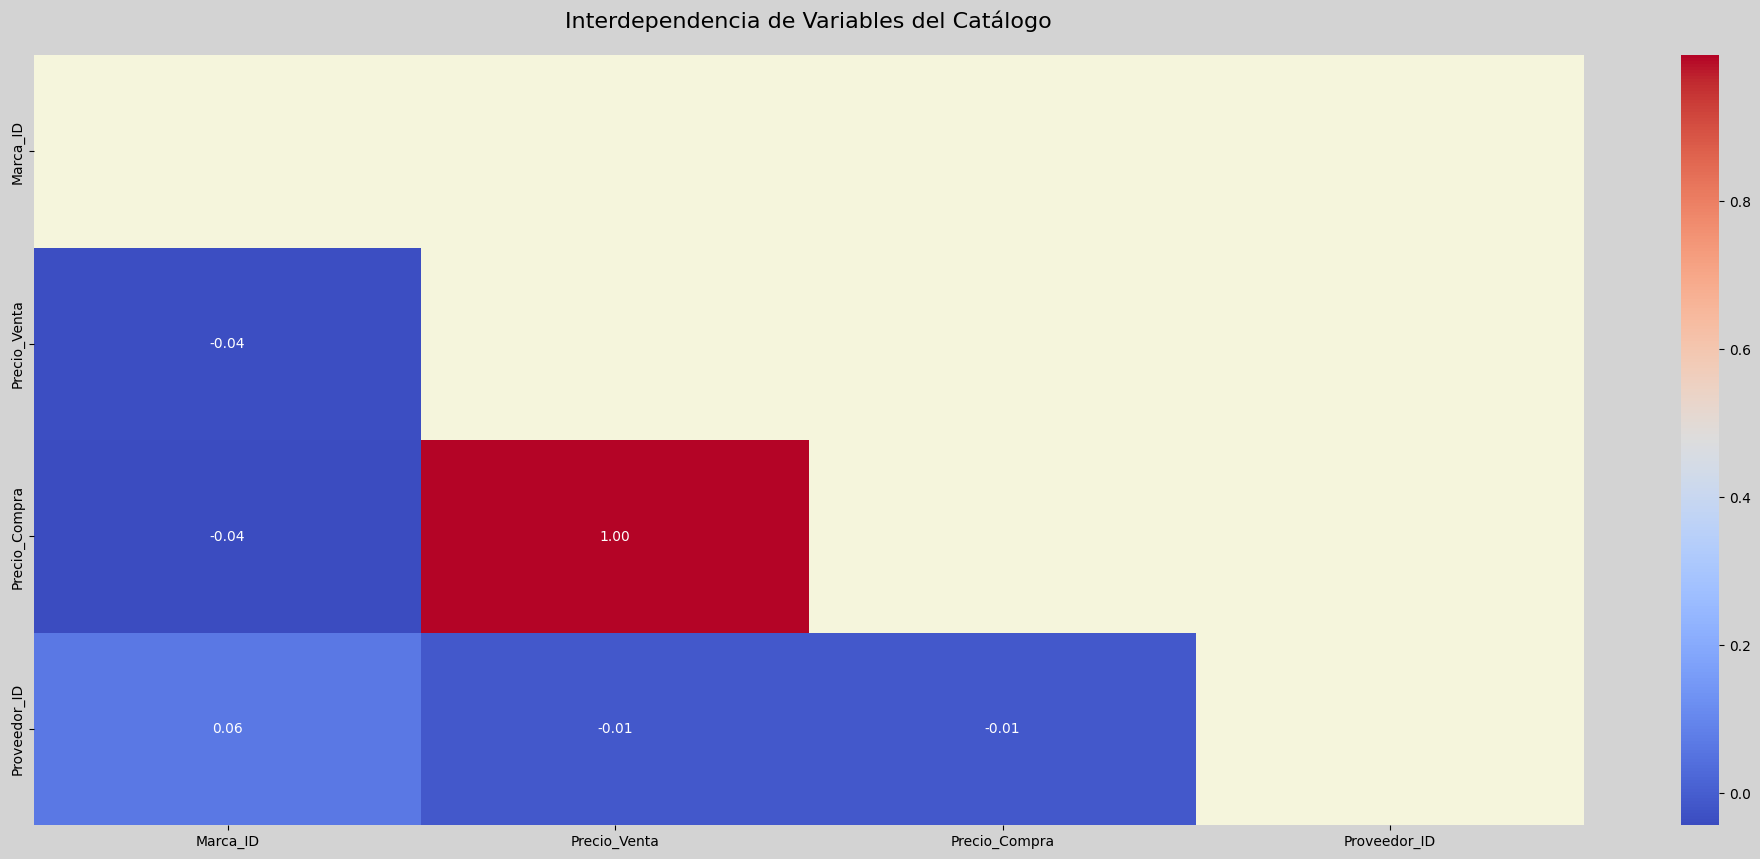

In [33]:
# Aislamos las variables cuantitativas y calculamos su correlación
df_num = df_catalogo_base.select_dtypes(include=[np.number])
coeficientes_corr = df_num.corr()

# Configuramos la máscara para mejorar la legibilidad del gráfico
matriz_mascara = np.zeros_like(coeficientes_corr, dtype=bool)
matriz_mascara[np.triu_indices_from(matriz_mascara)] = True

# Generación del mapa de calor (Heatmap)
plt.figure(figsize=(25, 10), facecolor='lightgray')
ax = sns.heatmap(coeficientes_corr, mask=matriz_mascara, annot=True, 
                 cmap='coolwarm', fmt='.2f', cbar=True)

ax.set_facecolor('beige')
plt.title('Interdependencia de Variables del Catálogo', fontsize=16, pad=20)
plt.show()

Paso 32: Análisis de Dispersión de Precios
- Descripción: "Graficamos la relación entre el costo de adquisición y el precio de salida al mercado. Este diagrama de dispersión permite visualizar el margen comercial y detectar si existen productos con precios fuera de la tendencia general."

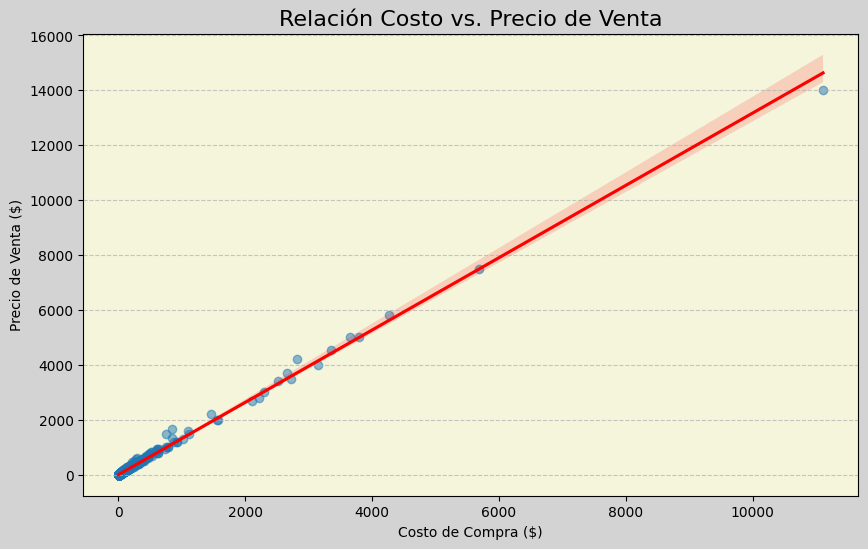

In [34]:
# Creación del gráfico de dispersión (Scatter Plot)
plt.figure(figsize=(10, 6), facecolor='lightgray')
sns.regplot(x='Precio_Compra', y='Precio_Venta', data=df_catalogo_base, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.gca().set_facecolor('beige')
plt.title('Relación Costo vs. Precio de Venta', fontsize=16)
plt.xlabel('Costo de Compra ($)')
plt.ylabel('Precio de Venta ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Paso 33: Distribución de Frecuencias (Histogramas)
- Descripción: "Ejecutamos una serie de histogramas con curvas de densidad para analizar cómo se distribuyen los precios y las clasificaciones. Este proceso permite identificar la concentración de productos en rangos de precios específicos."

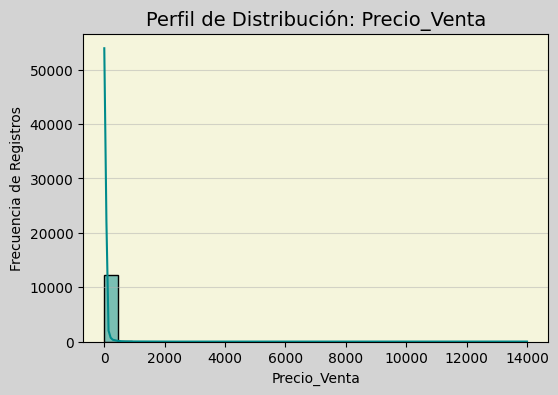

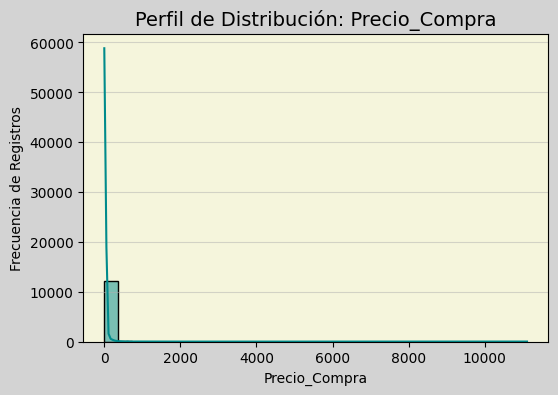

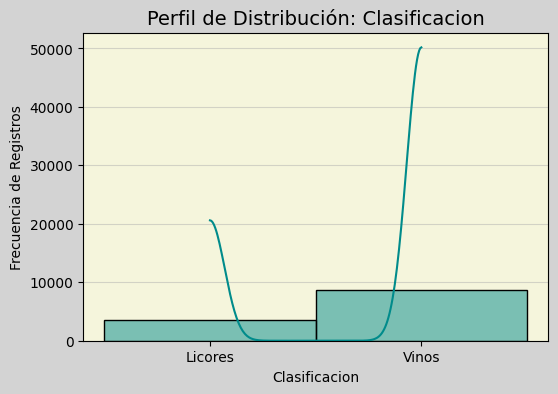

In [35]:
# Lista de variables para análisis de distribución
vars_distribucion = ['Precio_Venta', 'Precio_Compra', 'Clasificacion']

for var in vars_distribucion:
    plt.figure(figsize=(6, 4), facecolor='lightgray')
    
    # Renderizado del histograma con estimación de densidad
    sns.histplot(df_catalogo_base[var], kde=True, color='darkcyan', bins=30)
    
    plt.gca().set_facecolor('beige')
    plt.title(f'Perfil de Distribución: {var}', fontsize=14)
    plt.ylabel('Frecuencia de Registros')
    plt.grid(axis='y', alpha=0.5)
    plt.show()

Paso 34: Exportación del Catálogo Maestro Procesado
- Descripción: "Finalizamos el flujo de trabajo guardando el dataset ya limpio y transformado. Este archivo CSV constituye la tabla maestra de productos lista para ser utilizada en el cálculo de inventarios y reportes finales."

In [36]:
# Definimos la ruta de destino dentro de la carpeta de procesados
import os
os.makedirs('../data/DatosProcesados', exist_ok=True)
ruta_salida_productos = "../data/DatosProcesados/Productos_Limpios_Final.csv"

# Exportamos el DataFrame sin el índice de pandas
df_catalogo_base.to_csv(ruta_salida_productos, index=False)

print(f"Archivo guardado exitosamente en: {ruta_salida_productos}")

Archivo guardado exitosamente en: ../data/DatosProcesados/Productos_Limpios_Final.csv


Paso 35: Transformación a Modelo Dimensional (Split de Tablas)
- Descripción: "Segmentamos el catálogo maestro para aislar los atributos descriptivos del producto y sus metadatos de clasificación. Este proceso asegura que la dimensión de productos sea la única fuente de verdad para las descripciones, tamaños y marcas en todo el DWH."

In [37]:
# --- GENERACIÓN DE DIMENSIONES ---

# 1. Dim_Producto: Seleccionamos los atributos según el diagrama
# Columnas: Marca_ID, Descripcion, Tamaño, Volumen, Clasificacion, Pack
# Nota: Usamos el DataFrame final 'df_catalogo_base' resultante de tu limpieza 
columnas_dim_prod = ['Marca_ID', 'Descripcion', 'Tamaño', 'Volumen', 'Clasificacion', 'Pack']

dim_producto = df_catalogo_base[columnas_dim_prod].drop_duplicates().reset_index(drop=True)

# 2. Dim_Proveedor: También podemos extraer la relación base proveedor-producto aquí
dim_proveedor_base = df_catalogo_base[['Proveedor_ID', 'Nombre_Proveedor']].drop_duplicates().reset_index(drop=True)

Paso 36: Estandarización de Métricas de Catálogo
- Descripción: "Preparamos la tabla de referencia de precios y costos. Aunque estos valores suelen ser atributos, en este modelo se estructuran para alimentar las tablas de hechos de compras y ventas, asegurando que los precios de lista sean consistentes."

In [38]:
# Preparación de precios para integración con tablas de hechos
# Aseguramos que los tipos de datos sean correctos para SQL Server
df_catalogo_base['Precio_Compra'] = df_catalogo_base['Precio_Compra'].astype(float)
df_catalogo_base['Precio_Venta'] = df_catalogo_base['Precio_Venta'].astype(float)

Paso 37: Exportación Final a la Carpeta de Ingesta
- Descripción: "Persistimos la dimensión de productos saneada en la carpeta 'DatosIngesta'. Este archivo es el eje central del modelo estrella, permitiendo que las ventas, compras e inventarios se vinculen a una descripción única de artículo."

In [39]:
# Definición de la ruta de salida para ingesta
import os
os.makedirs('../data/DatosIngesta', exist_ok=True)
ruta_ingesta = "../data/DatosIngesta/"

# Exportación definitiva de la dimensión
dim_producto.to_csv(ruta_ingesta + "Dim_Producto.csv", index=False)

# Opcional: Guardamos la base de proveedores si no se generó en Compras
dim_proveedor_base.to_csv(ruta_ingesta + "Dim_Proveedor_Base.csv", index=False)

print(f"--- DIMENSIÓN DE PRODUCTOS GENERADA ---")
print(f"Archivo guardado en: {ruta_ingesta}Dim_Producto.csv")

--- DIMENSIÓN DE PRODUCTOS GENERADA ---
Archivo guardado en: ../data/DatosIngesta/Dim_Producto.csv
